In [ ]:

# Cell 1
!nvidia-smi
!pip install tensorflow opencv-python matplotlib


Sat Mar 14 22:51:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from glob import glob

print("TensorFlow:", tf.__version__)
print("OpenCV:", cv2.__version__)

print("Librerías cargadas correctamente")

TensorFlow: 2.18.0
OpenCV: 4.12.0
Librerías cargadas correctamente


In [ ]:
!cp -r /content/drive/MyDrive/dataset /content/
!mkdir -p /content/dataset
!tar -xf /content/dataset/dataset.tar -C /content/dataset

In [ ]:
IMG_HEIGHT = 240
IMG_WIDTH = 320

BATCH_SIZE = 16
EPOCHS = 80

NUM_CLASSES = 5

DATASET_IMG = "/content/dataset/color"
DATASET_MASK = "/content/dataset/label_index"

CHECKPOINT_DIR = "/content/drive/MyDrive/model"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)


print("Configuración de entrenamiento")
print("Resolución:", IMG_WIDTH, "x", IMG_HEIGHT)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Clases:", NUM_CLASSES)

print("Checkpoint dir:", CHECKPOINT_DIR)

Configuración de entrenamiento
Resolución: 320 x 240
Batch size: 16
Epochs: 80
Clases: 5
Checkpoint dir: /content/drive/MyDrive/model


In [ ]:
image_paths = sorted(glob(DATASET_IMG + "/*.png"))
mask_paths = sorted(glob(DATASET_MASK + "/*.png"))

print("imagenes:", len(image_paths))
print("mascaras:", len(mask_paths))

print("Número de imágenes:", len(image_paths))
print("Número de máscaras:", len(mask_paths))

print("Primer imagen:", image_paths[0])
print("Primer máscara:", mask_paths[0])
assert len(image_paths) == len(mask_paths)

imagenes: 10919
mascaras: 10919
Número de imágenes: 10919
Número de máscaras: 10919
Primer imagen: /content/dataset/color/1693274724086398208.png
Primer máscara: /content/dataset/label_index/1693274724086398208.png


In [ ]:
def load_image(img_path, mask_path):

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img,(IMG_WIDTH,IMG_HEIGHT))

    mask = cv2.imread(mask_path,0)
    mask = cv2.resize(mask,(IMG_WIDTH,IMG_HEIGHT),
                      interpolation=cv2.INTER_NEAREST)

    img = img.astype(np.float32)/255.0

    return img,mask

img,mask = load_image(image_paths[0],mask_paths[0])

print("Shape imagen:", img.shape)
print("Shape máscara:", mask.shape)

print("Tipo imagen:", img.dtype)
print("Tipo máscara:", mask.dtype)

print("Valores máscara únicos:", np.unique(mask))

Shape imagen: (240, 320, 3)
Shape máscara: (240, 320)
Tipo imagen: float32
Tipo máscara: uint8
Valores máscara únicos: [0 2 3 4]


In [ ]:
def augment(img, mask):

    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)

        mask = tf.expand_dims(mask, -1)
        mask = tf.image.flip_left_right(mask)
        mask = tf.squeeze(mask, -1)

    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.8, 1.2)

    noise = tf.random.normal(tf.shape(img), 0, 0.02)
    img= tf.clip_by_value(img + noise, 0, 1)

    return img, mask

print("Augmentation OK")
print("Shape imagen:", img.shape)
print("Shape máscara:", mask.shape)
print("Clases en máscara original:", np.unique(mask))
print("Clases en máscara augmentada:", np.unique(mask))

Augmentation OK
Shape imagen: (240, 320, 3)
Shape máscara: (240, 320)
Clases en máscara original: [0 2 3 4]
Clases en máscara augmentada: [0 2 3 4]


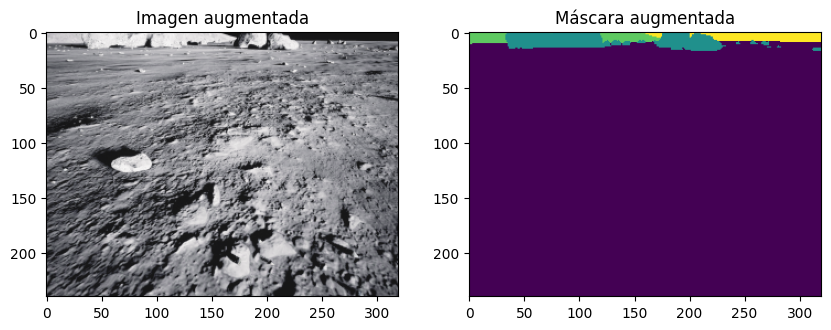

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Imagen augmentada")

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title("Máscara augmentada")

plt.show()

In [ ]:
def load_tf(img_path, mask_path):

    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (IMG_HEIGHT, IMG_WIDTH))
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, (IMG_HEIGHT, IMG_WIDTH), method="nearest")
    mask = tf.squeeze(mask, axis=-1)

    return img, mask


In [ ]:
dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
dataset = dataset.cache()
dataset = dataset.shuffle(2000)

dataset = dataset.map(
    lambda x,y: load_tf(x,y),
    num_parallel_calls=tf.data.AUTOTUNE
)

dataset = dataset.map(
    lambda x,y: augment(x,y),
    num_parallel_calls=tf.data.AUTOTUNE
)

dataset = dataset.batch(BATCH_SIZE)
dataset = dataset.repeat()
dataset = dataset.prefetch(tf.data.AUTOTUNE)

for imgs, masks in dataset.take(1):
    print("Batch imágenes:", imgs.shape)
    print("Batch máscaras:", masks.shape)

    print("Min pixel:", tf.reduce_min(imgs).numpy())
    print("Max pixel:", tf.reduce_max(imgs).numpy())

Batch imágenes: (16, 240, 320, 3)
Batch máscaras: (16, 240, 320)
Min pixel: 0.0
Max pixel: 1.0


In [ ]:
def dsconv(x, filters, stride=1):

    shortcut = x

    x = tf.keras.layers.SeparableConv2D(
        filters, 3,
        strides=stride,
        padding="same",
        use_bias=False
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.SeparableConv2D(
        filters, 3,
        padding="same",
        use_bias=False
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = tf.keras.layers.Conv2D(filters,1,strides=stride,padding="same")(shortcut)

    x = tf.keras.layers.Add()([x, shortcut])
    x = tf.keras.layers.ReLU()(x)

    return x

In [ ]:
def load_latest_model():

    checkpoints = sorted(
        glob(CHECKPOINT_DIR + "/*.keras"),
        key=lambda x: int(x.split("_")[-1].split(".")[0])
    )

    print("Checkpoints encontrados:", len(checkpoints))

    if len(checkpoints) == 0:
        print("No checkpoint found")
        return None, 0

    latest = checkpoints[-1]

    print("Loading checkpoint:", latest)

    model = tf.keras.models.load_model(
        latest,
        custom_objects={"SparseMeanIoU": SparseMeanIoU}
    )

    epoch = int(latest.split("_")[-1].split(".")[0])

    print("Último epoch:", epoch)

    return model, epoch

In [ ]:
class SparseMeanIoU(tf.keras.metrics.MeanIoU):

    def __init__(self, num_classes, name="mean_iou", **kwargs):
        super().__init__(num_classes=num_classes, name=name, **kwargs)

    def update_state(self, y_true, y_pred, sample_weight=None):

        y_pred = tf.argmax(y_pred, axis=-1)
        y_pred = tf.cast(y_pred, tf.int32)

        return super().update_state(y_true, y_pred, sample_weight)

In [ ]:
def terrain_unet(input_shape=(240,320,3), classes=5):

    inputs = tf.keras.Input(input_shape)

    # Encoder
    e1 = dsconv(inputs, 32)
    p1 = tf.keras.layers.MaxPooling2D()(e1)

    e2 = dsconv(p1, 64)
    p2 = tf.keras.layers.MaxPooling2D()(e2)

    e3 = dsconv(p2, 128)
    p3 = tf.keras.layers.MaxPooling2D()(e3)

    e4 = dsconv(p3, 256)
    p4 = tf.keras.layers.MaxPooling2D()(e4)

    # Bottleneck
    b = tf.keras.layers.SeparableConv2D(
      512,3,dilation_rate=2,padding="same",use_bias=False)(p4)
    b = tf.keras.layers.BatchNormalization()(b)
    b = tf.keras.layers.ReLU()(b)

    # Decoder
    u1 = tf.keras.layers.UpSampling2D()(b)
    u1 = tf.keras.layers.Concatenate()([u1, e4])
    d1 = dsconv(u1, 256)

    u2 = tf.keras.layers.UpSampling2D()(d1)
    u2 = tf.keras.layers.Concatenate()([u2, e3])
    d2 = dsconv(u2, 128)

    u3 = tf.keras.layers.UpSampling2D()(d2)
    u3 = tf.keras.layers.Concatenate()([u3, e2])
    d3 = dsconv(u3, 64)

    u4 = tf.keras.layers.UpSampling2D()(d3)
    u4 = tf.keras.layers.Concatenate()([u4, e1])
    d4 = dsconv(u4, 32)

    outputs = tf.keras.layers.Conv2D(
        classes,
        1,
        activation="softmax"
    )(d4)

    model = tf.keras.Model(inputs, outputs)

    return model
model, initial_epoch = load_latest_model()

if model is None:

    print("Creando modelo nuevo")

    model = terrain_unet((240,320,3), classes=NUM_CLASSES)

    initial_epoch = 0

else:

    print("Reanudando entrenamiento desde epoch", initial_epoch)

model.summary()
print("Total parámetros:", model.count_params())

Checkpoints encontrados: 50
Loading checkpoint: /content/drive/MyDrive/model/model_epoch_050.keras
Último epoch: 50
Reanudando entrenamiento desde epoch 50


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 240, 320,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 240, 320,  │        123 │ input_layer[0][0] │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 240, 320,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 240, 320,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 240, 320,  │      1,312 │ re_lu[0][0]       │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 240, 320,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 240, 320,  │        128 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 240, 320,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 240, 320,  │          0 │ add[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 120, 160,  │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 120, 160,  │      2,336 │ max_pooling2d[0]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 120, 160,  │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 120, 160,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_3  │ (None, 120, 160,  │      4,672 │ re_lu_2[0][0]     │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 120, 160,  │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 120, 160,  │      2,112 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 120, 160,  │          0 │ batch_normalizat

 Total params: 2,841,474 (10.84 MB)

 Trainable params: 945,536 (3.61 MB)

 Non-trainable params: 4,864 (19.00 KB)

 Optimizer params: 1,891,074 (7.21 MB)

Total parámetros: 950400


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        SparseMeanIoU(NUM_CLASSES)
    ]
)
print("Modelo compilado")
print("Optimizer:", model.optimizer)
print("Loss:", model.loss)

Modelo compilado
Optimizer: <keras.src.optimizers.adam.Adam object at 0x7a914a1006d0>
Loss: sparse_categorical_crossentropy


In [ ]:
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(

    filepath=CHECKPOINT_DIR+"/model_epoch_{epoch:03d}.keras",

    save_weights_only=False,

    save_freq="epoch",

    verbose=1
)

callbacks = [

    checkpoint_callback,

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="loss",
        factor=0.5,
        patience=5
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="loss",
        patience=10
    )
]
print("Callbacks configurados")
print("Checkpoint path:", CHECKPOINT_DIR)

Callbacks configurados
Checkpoint path: /content/drive/MyDrive/model


In [ ]:
img, mask = load_image(image_paths[0], mask_paths[0])

pred = model.predict(img[None])

print(pred.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
(1, 240, 320, 5)


In [ ]:
history = model.fit(

    dataset,

    steps_per_epoch=len(image_paths)//BATCH_SIZE,

    epochs=EPOCHS,

    initial_epoch=initial_epoch,

    callbacks=callbacks
)

Epoch 51/80
682/682 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.9958 - loss: 0.0105 - mean_iou: 0.9617
Epoch 51: saving model to /content/drive/MyDrive/model/model_epoch_051.keras
682/682 ━━━━━━━━━━━━━━━━━━━━ 265s 316ms/step - accuracy: 0.9958 - loss: 0.0105 - mean_iou: 0.9617 - learning_rate: 1.0000e-04
Epoch 52/80
682/682 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.9959 - loss: 0.0103 - mean_iou: 0.9629
Epoch 52: saving model to /content/drive/MyDrive/model/model_epoch_052.keras
682/682 ━━━━━━━━━━━━━━━━━━━━ 241s 317ms/step - accuracy: 0.9959 - loss: 0.0103 - mean_iou: 0.9629 - learning_rate: 1.0000e-04
Epoch 53/80
682/682 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.9959 - loss: 0.0103 - mean_iou: 0.9626
Epoch 53: saving model to /content/drive/MyDrive/model/model_epoch_053.keras
682/682 ━━━━━━━━━━━━━━━━━━━━ 216s 317ms/step - accuracy: 0.9959 - loss: 0.0103 - mean_iou: 0.9626 - learning_rate: 1.0000e-04
Epoch 54/80
682/682 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open("rover_model.tflite","wb") as f:

    f.write(tflite_model)

print("Convirtiendo modelo a TFLite...")

print("Tamaño modelo keras (aprox):",
      model.count_params()*4/1e6,"MB")
print("TFLite generado correctamente")

In [ ]:
def representative_dataset():

    for i in range(100):

        img,_ = load_image(image_paths[i],mask_paths[i])

        img = np.expand_dims(img,0)

        yield [img]


converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

converter.representative_dataset = representative_dataset

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

tflite_model = converter.convert()

with open("rover_model_int8.tflite","wb") as f:

    f.write(tflite_model)

print("Iniciando cuantización INT8")
print("Usando 100 imágenes representativas")
print("Modelo INT8 generado")

In [ ]:
img,_ = load_image(image_paths[0],mask_paths[0])

pred = model.predict(img[None])

pred = np.argmax(pred[0],axis=-1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("imagen")

plt.subplot(1,2,2)
plt.imshow(pred)
plt.title("segmentacion")

plt.show()

print("Ejecutando inferencia de prueba")

print("Shape predicción:", pred.shape)

print("Clases detectadas:", np.unique(pred))